# Part A: Data preprocessing 

0. Imports and configs 


In [1]:
import os
import random
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter
import tensorflow as tf

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32

IMAGES_DIR = Path("data/images/Images")
ANNOTATIONS_DIR = Path("data/annotations/Annotation")

1. Functions 

In [2]:
import os
import random
import subprocess
import xml.etree.ElementTree as ET
from pathlib import Path
from collections import Counter

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

IMAGES_DIR = Path("data/images/Images")
ANNOTATIONS_DIR = Path("data/annotations/Annotation")


def parse_annotation(annotation_path):
    """Parse XML annotation and return normalized bbox as [xmin, ymin, xmax, ymax]."""
    tree = ET.parse(annotation_path)
    root = tree.getroot()

    size = root.find("size")
    width = int(size.find("width").text)
    height = int(size.find("height").text)

    obj = root.find("object")
    bndbox = obj.find("bndbox")

    xmin = int(bndbox.find("xmin").text) / width
    ymin = int(bndbox.find("ymin").text) / height
    xmax = int(bndbox.find("xmax").text) / width
    ymax = int(bndbox.find("ymax").text) / height

    return [xmin, ymin, xmax, ymax]


def crop_with_bbox(img, bbox):
    """
    Crop image using normalized bbox.
    tf.image.crop_and_resize expects boxes in [ymin, xmin, ymax, xmax].
    """
    xmin, ymin, xmax, ymax = tf.unstack(bbox)
    boxes = tf.stack([[ymin, xmin, ymax, xmax]])
    box_indices = tf.constant([0], dtype=tf.int32)

    img = tf.expand_dims(img, axis=0)  # [1, H, W, 3]
    cropped = tf.image.crop_and_resize(
        img,
        boxes=boxes,
        box_indices=box_indices,
        crop_size=(IMG_SIZE, IMG_SIZE)
    )
    return tf.squeeze(cropped, axis=0)


def load_and_preprocess(image_path, label, bbox, use_bbox=True):
    """Load image, crop to bbox, resize, normalize."""
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

    if use_bbox:
        img = crop_with_bbox(img, bbox)
    else:
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    return img, label


def build_dataset(paths, labels, bboxes, shuffle=False, training=False, use_bbox=True):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels, bboxes))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda p, y, b: load_and_preprocess(p, y, b, use_bbox=use_bbox),
        num_parallel_calls=AUTOTUNE
    )

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


def plot_breed_distribution(y_train, y_val, y_test, label_to_breed, num_classes):
    breed_names = [label_to_breed[i] for i in range(num_classes)]
    train_counts = [np.sum(y_train == i) for i in range(num_classes)]
    val_counts = [np.sum(y_val == i) for i in range(num_classes)]
    test_counts = [np.sum(y_test == i) for i in range(num_classes)]

    y_pos = np.arange(num_classes)
    bar_h = 0.25

    fig, ax = plt.subplots(figsize=(10, 12))
    ax.barh(y_pos - bar_h, train_counts, bar_h, label=f"Train ({len(y_train)})")
    ax.barh(y_pos, val_counts, bar_h, label=f"Val ({len(y_val)})")
    ax.barh(y_pos + bar_h, test_counts, bar_h, label=f"Test ({len(y_test)})")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(breed_names, fontsize=9)
    ax.set_xlabel("Number of Images")
    ax.set_title("Samples per Breed by Split")
    ax.legend()
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

2. Downlaoding the data, donwloads only once

#set up kaggle credential for download


In [3]:


DATA_DIR = Path("data")

if not DATA_DIR.exists():
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "jessicali9530/stanford-dogs-dataset", "--unzip", "-p", "./data"],
        capture_output=True,
        text=True,
    )

    if result.returncode == 0:
        print("Dataset downloaded and extracted to ./data")
    else:
        stderr = (result.stderr or "").strip()
        missing_auth = (
            "KeyError: 'username'" in stderr
            or "Could not find kaggle.json" in stderr
            or "credentials" in stderr.lower()
        )

        if missing_auth:
            print("Kaggle credentials were not found on this machine.")
            print("Each user should configure their own Kaggle account locally:")
            print("  1) Create ~/.kaggle/kaggle.json with your own username and API key")
            print("  2) Run: chmod 600 ~/.kaggle/kaggle.json")
            print("  3) Re-run this cell")
        else:
            print(f"Download failed:\n{stderr}")
else:
    print("Dataset already exists at ./data")

Dataset already exists at ./data


2. Breed selection and label mapping

In [4]:
SELECTED_BREEDS = [
    "n02085620-Chihuahua",
    "n02086240-Shih-Tzu",
    "n02087394-Rhodesian_ridgeback",
    "n02088364-beagle",
    "n02089973-English_foxhound",
    "n02091032-Italian_greyhound",
    "n02092339-Weimaraner",
    "n02093256-Staffordshire_bullterrier",
    "n02094433-Yorkshire_terrier",
    "n02096585-Boston_bull",
    "n02097047-miniature_schnauzer",
    "n02099601-golden_retriever",
    "n02099712-Labrador_retriever",
    "n02100877-Irish_setter",
    "n02102318-cocker_spaniel",
    "n02105855-Shetland_sheepdog",
    "n02106166-Border_collie",
    "n02106382-Bouvier_des_Flandres",
    "n02106550-Rottweiler",
    "n02106662-German_shepherd",
    "n02107142-Doberman",
    "n02107683-Bernese_mountain_dog",
    "n02108089-boxer",
    "n02108915-French_bulldog",
    "n02109047-Great_Dane",
    "n02109525-Saint_Bernard",
    "n02110185-Siberian_husky",
    "n02110958-pug",
    "n02111889-Samoyed",
    "n02112018-Pomeranian",
]

breed_to_label = {breed: i for i, breed in enumerate(SELECTED_BREEDS)} #labels are numerical class
label_to_breed = {i: breed.split("-", 1)[1] for i, breed in enumerate(SELECTED_BREEDS)}
NUM_CLASSES = len(SELECTED_BREEDS)

print(f"Selected {NUM_CLASSES} breeds:")
for i, breed in label_to_breed.items():
    print(f"  {i:2d}: {breed}")

Selected 30 breeds:
   0: Chihuahua
   1: Shih-Tzu
   2: Rhodesian_ridgeback
   3: beagle
   4: English_foxhound
   5: Italian_greyhound
   6: Weimaraner
   7: Staffordshire_bullterrier
   8: Yorkshire_terrier
   9: Boston_bull
  10: miniature_schnauzer
  11: golden_retriever
  12: Labrador_retriever
  13: Irish_setter
  14: cocker_spaniel
  15: Shetland_sheepdog
  16: Border_collie
  17: Bouvier_des_Flandres
  18: Rottweiler
  19: German_shepherd
  20: Doberman
  21: Bernese_mountain_dog
  22: boxer
  23: French_bulldog
  24: Great_Dane
  25: Saint_Bernard
  26: Siberian_husky
  27: pug
  28: Samoyed
  29: Pomeranian


3. GOes through each image, the image is added to img_paths list, the bb are extracted and normalized and added into the bboxes list, and the label(which is the dog bread) is added to the labels list. 

In [5]:
image_paths = []  #array of image paths
labels = [] #array of labels which is the dog bread
bboxes = [] #array of bounding boxes, each element is a list of 4 numbers [xmin, ymin, xmax, ymax]
skipped = 0 #number of images skipped



for breed_folder in SELECTED_BREEDS:
    label = breed_to_label[breed_folder]
    img_dir = IMAGES_DIR / breed_folder
    ann_dir = ANNOTATIONS_DIR / breed_folder

    for img_file in sorted(img_dir.glob("*.jpg")):
        ann_file = ann_dir / img_file.stem
        if not ann_file.exists():
            skipped += 1
            continue
        try:
            bbox = parse_annotation(ann_file) # function to parse the annotation and return the normalized bounding box for the gicen image
            image_paths.append(str(img_file))
            labels.append(label)
            bboxes.append(bbox)
        except Exception:
            skipped += 1

image_paths = np.array(image_paths)
labels = np.array(labels)
bboxes = np.array(bboxes, dtype=np.float32)

print(f"Total samples: {len(image_paths)} (skipped {skipped})")
print(f"Labels shape: {labels.shape}, Bboxes shape: {bboxes.shape}")
print(f"\nSamples per breed:")
counts = Counter(labels)
for lbl in sorted(counts):
    print(f"  {label_to_breed[lbl]:30s}: {counts[lbl]}")

Total samples: 5116 (skipped 0)
Labels shape: (5116,), Bboxes shape: (5116, 4)

Samples per breed:
  Chihuahua                     : 152
  Shih-Tzu                      : 214
  Rhodesian_ridgeback           : 172
  beagle                        : 195
  English_foxhound              : 157
  Italian_greyhound             : 182
  Weimaraner                    : 160
  Staffordshire_bullterrier     : 155
  Yorkshire_terrier             : 164
  Boston_bull                   : 182
  miniature_schnauzer           : 154
  golden_retriever              : 150
  Labrador_retriever            : 171
  Irish_setter                  : 155
  cocker_spaniel                : 159
  Shetland_sheepdog             : 157
  Border_collie                 : 150
  Bouvier_des_Flandres          : 150
  Rottweiler                    : 152
  German_shepherd               : 152
  Doberman                      : 150
  Bernese_mountain_dog          : 218
  boxer                         : 151
  French_bulldog           

4. Stratified split: 70% train, 15% validation, 15% test
stratify=labels ensures each breed has the same proportion in every split

In [6]:
X_train, X_temp, y_train, y_temp, bbox_train, bbox_temp = train_test_split( #splits into 70% train, and 30% temp
    image_paths, labels, bboxes,
    test_size=0.30, stratify=labels, random_state=SEED
)

X_val, X_test, y_val, y_test, bbox_val, bbox_test = train_test_split( #the 30 temp is split into 15% val and 15% test
    X_temp, y_temp, bbox_temp,
    test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:      {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")
print(f"Test:       {len(X_test)} samples")

print(f"\nBreed distribution check (first 5 breeds):")
for lbl in range(5):
    name = label_to_breed[lbl]
    tr = np.sum(y_train == lbl)
    va = np.sum(y_val == lbl)
    te = np.sum(y_test == lbl)
    print(f"  {name:25s} -> train={tr}, val={va}, test={te}")

Train:      3581 samples
Validation: 767 samples
Test:       768 samples

Breed distribution check (first 5 breeds):
  Chihuahua                 -> train=106, val=23, test=23
  Shih-Tzu                  -> train=150, val=32, test=32
  Rhodesian_ridgeback       -> train=120, val=26, test=26
  beagle                    -> train=137, val=29, test=29
  English_foxhound          -> train=110, val=24, test=23


5. Breed distribution across each split

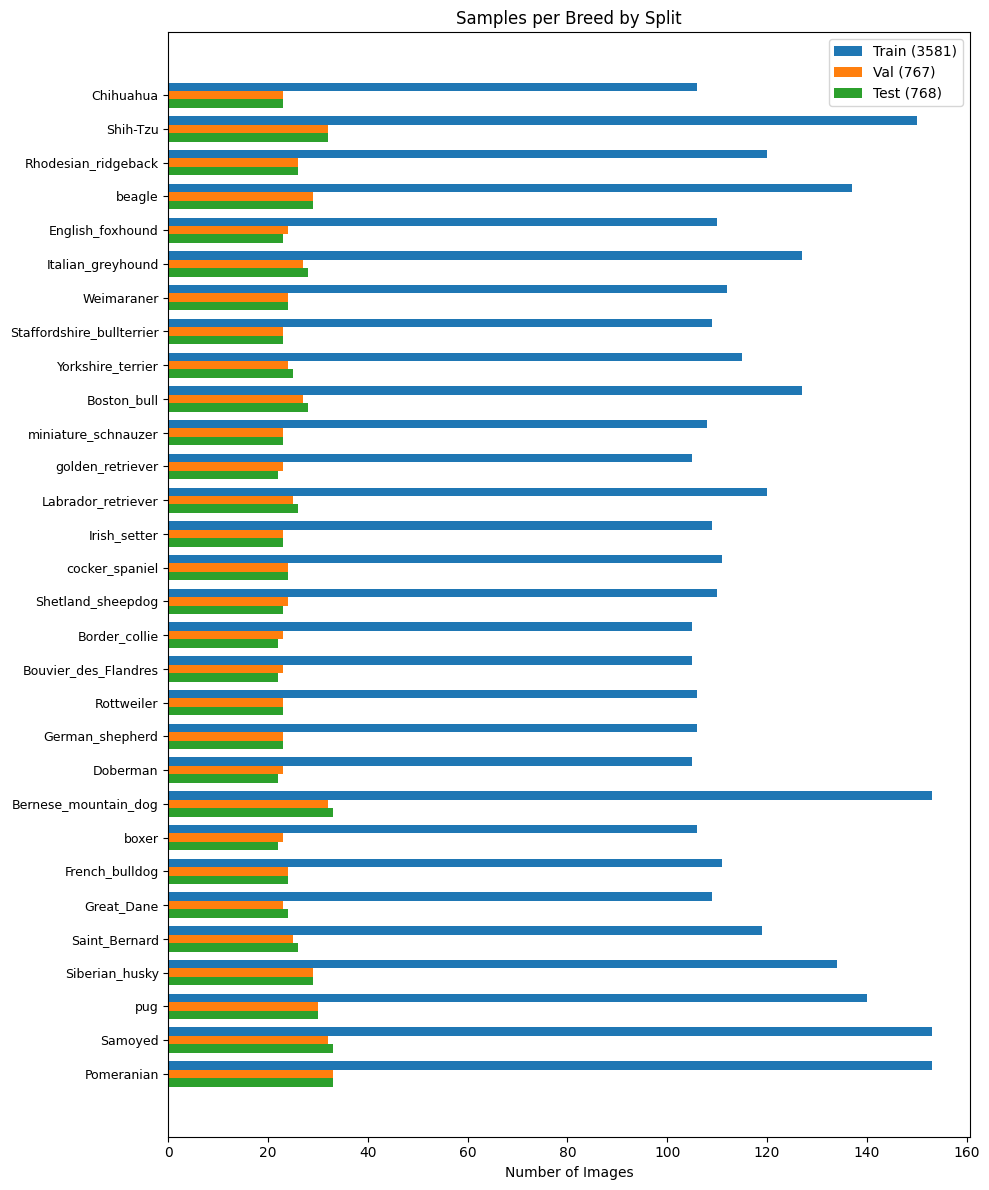

In [7]:
plot_breed_distribution(y_train, y_val, y_test, label_to_breed, NUM_CLASSES)

6. Sanity Check: checking one batch of the trainig to make sure everything is build correctly. 

In [8]:
train_ds = build_dataset(X_train, y_train, bbox_train, shuffle=True, training=True, use_bbox=True)
val_ds   = build_dataset(X_val, y_val, bbox_val, shuffle=False, training=False, use_bbox=True)
test_ds  = build_dataset(X_test, y_test, bbox_test, shuffle=False, training=False, use_bbox=True)

for images, labels_batch in train_ds.take(1):
    print(f"Image batch shape:  {images.shape}")
    print(f"Labels batch shape: {labels_batch.shape}")
    print(f"Pixel range: [{images.numpy().min():.2f}, {images.numpy().max():.2f}]")

Image batch shape:  (32, 224, 224, 3)
Labels batch shape: (32,)
Pixel range: [0.00, 1.00]


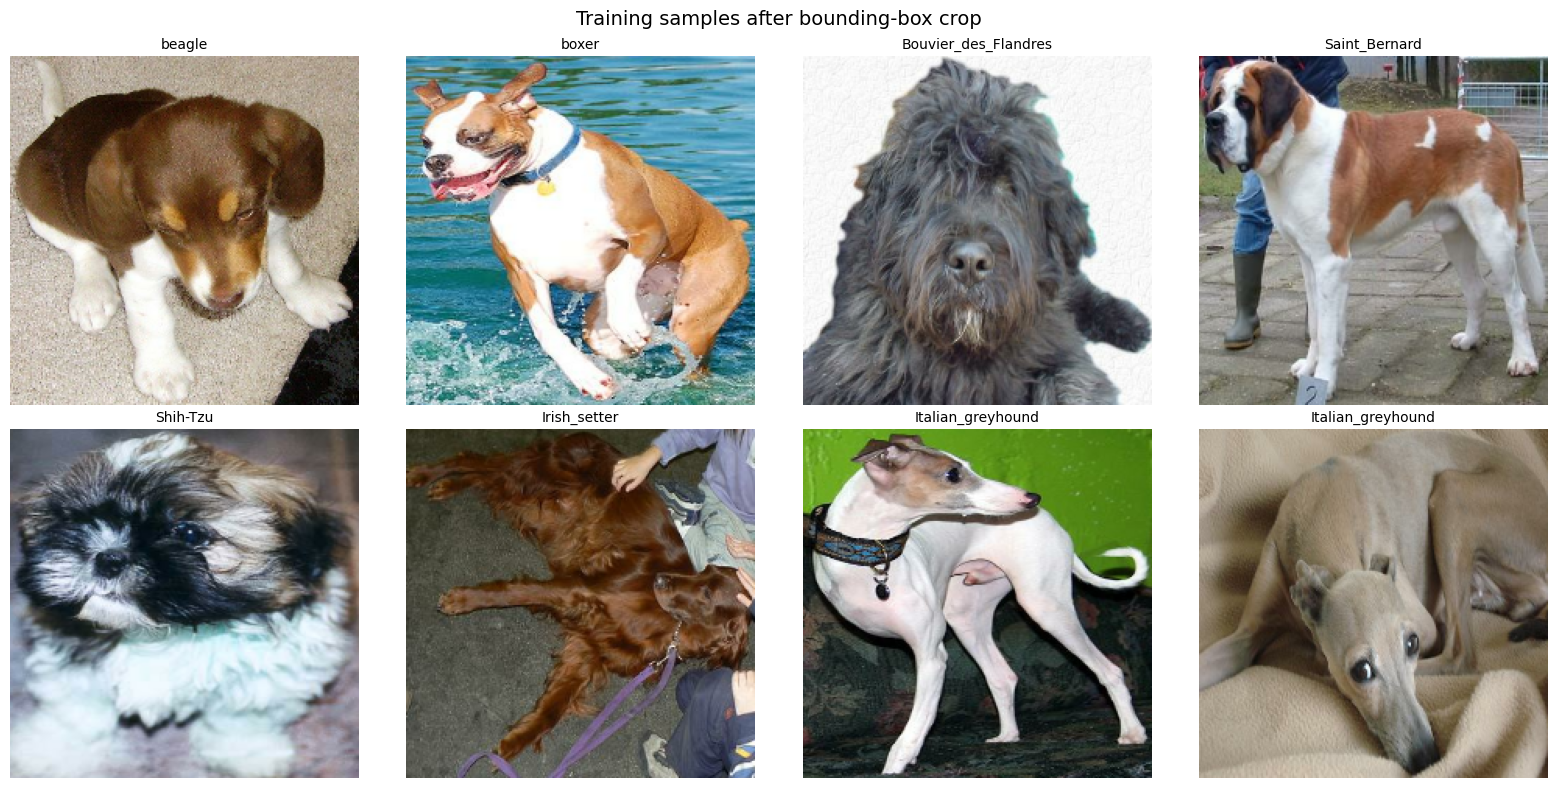

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for images, labels_batch in train_ds.take(1):
    for i in range(8):
        img = images[i].numpy()
        label = labels_batch[i].numpy()

        axes[i].imshow(img)
        axes[i].set_title(label_to_breed[label], fontsize=10)
        axes[i].axis("off")

plt.suptitle("Training samples after bounding-box crop", fontsize=14)
plt.tight_layout()
plt.show()

# Part B: Model Develpment

In [10]:
from tensorflow.keras import layers, models, regularizers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="cnn_data_augmentation")


def build_cnn_model(conv_filters=(32, 64, 128), dense_units=128, dropout_rate=0.4, l2_strength=1e-4):
    """
    Max 3 convolution layers, as requested.
    No Flatten.
    Uses GlobalAveragePooling2D to reduce overfitting.
    """
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)
    x = layers.Rescaling(255.0)(x)
   

    for filters in conv_filters:
        x = layers.Conv2D(
            filters,
            (3, 3),
            padding="same",
            kernel_regularizer=regularizers.l2(l2_strength)
        )(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_strength)
    )(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="dog_breed_cnn")
    return model



In [11]:
#best architecture
architecture_candidates = [
    {"name": "A1_small", "conv_filters": (32, 64, 128), "dense_units": 128, "dropout_rate": 0.35, "l2_strength": 1e-4},
    {"name": "A2_medium", "conv_filters": (32, 64, 96),  "dense_units": 128, "dropout_rate": 0.40, "l2_strength": 1e-4},
    {"name": "A3_strong_reg", "conv_filters": (32, 64, 128), "dense_units": 96, "dropout_rate": 0.50, "l2_strength": 3e-4},
]

architecture_results = []

for cfg in architecture_candidates:
    print(f"\nTesting architecture: {cfg['name']}")

    model = build_cnn_model(
        conv_filters=cfg["conv_filters"],
        dense_units=cfg["dense_units"],
        dropout_rate=cfg["dropout_rate"],
        l2_strength=cfg["l2_strength"]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=12,
        callbacks=callbacks,
        verbose=1
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    architecture_results.append({
        "name": cfg["name"],
        "config": cfg,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss
    })

architecture_results = sorted(
    architecture_results,
    key=lambda x: (x["best_val_acc"], -x["best_val_loss"]),
    reverse=True
)

best_architecture = architecture_results[0]
print("\nBest architecture:")
print(best_architecture)


Testing architecture: A1_small
Epoch 1/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 107s 943ms/step - accuracy: 0.0679 - loss: 3.3958 - val_accuracy: 0.0652 - val_loss: 3.3961 - learning_rate: 0.0010
Epoch 2/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.0941 - loss: 3.2631 - val_accuracy: 0.0652 - val_loss: 3.3596 - learning_rate: 0.0010
Epoch 3/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.1125 - loss: 3.1855 - val_accuracy: 0.1082 - val_loss: 3.2147 - learning_rate: 0.0010
Epoch 4/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.1237 - loss: 3.1518 - val_accuracy: 0.1004 - val_loss: 3.3100 - learning_rate: 0.0010
Epoch 5/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.1299 - loss: 3.1184 - val_accuracy: 0.1291 - val_loss: 3.1346 - learning_rate: 0.0010
Epoch 6/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.1421 - loss: 3.0911 - val_accuracy: 0.0821 - val_loss: 3.3897 - learning_rate: 0.0010
Epoch 7/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 126s 1s

In [12]:
#best learning rate 
# ✅ Get best architecture config
best_cfg = best_architecture["config"]

# ✅ FIND BEST LEARNING RATE 
learning_rates = [1e-4, 3e-4, 1e-3]
lr_results = []

for lr in learning_rates:
    print(f"\nTesting learning rate: {lr}")

    model = build_cnn_model(
        conv_filters=best_cfg["conv_filters"],
        dense_units=best_cfg["dense_units"],
        dropout_rate=best_cfg["dropout_rate"],
        l2_strength=best_cfg["l2_strength"]
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=12,
        callbacks=callbacks,
        verbose=1
    )

    best_val_acc = max(history.history["val_accuracy"])
    best_val_loss = min(history.history["val_loss"])

    lr_results.append({
        "lr": lr,
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss
    })

lr_results = sorted(
    lr_results,
    key=lambda x: (x["best_val_acc"], -x["best_val_loss"]),
    reverse=True
)

best_lr = lr_results[0]["lr"]

print("\nBest learning rate:", best_lr)
print(lr_results)


Testing learning rate: 0.0001
Epoch 1/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.0327 - loss: 3.6724 - val_accuracy: 0.0365 - val_loss: 3.4264 - learning_rate: 1.0000e-04
Epoch 2/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.0497 - loss: 3.4946 - val_accuracy: 0.0574 - val_loss: 3.3376 - learning_rate: 1.0000e-04
Epoch 3/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.0687 - loss: 3.4062 - val_accuracy: 0.1173 - val_loss: 3.2968 - learning_rate: 1.0000e-04
Epoch 4/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.0740 - loss: 3.3705 - val_accuracy: 0.1278 - val_loss: 3.2679 - learning_rate: 1.0000e-04
Epoch 5/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.0857 - loss: 3.3350 - val_accuracy: 0.1330 - val_loss: 3.2365 - learning_rate: 1.0000e-04
Epoch 6/12
112/112 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.0930 - loss: 3.3059 - val_accuracy: 0.1408 - val_loss: 3.2188 - learning_rate: 1.0000e-04
Epoch 7/12
112/112 ━━━━━━━━

In [14]:
final_model = build_cnn_model(
    conv_filters=best_cfg["conv_filters"],
    dense_units=best_cfg["dense_units"],
    dropout_rate=best_cfg["dropout_rate"],
    l2_strength=best_cfg["l2_strength"]
)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_lr),
    loss="sparse_categorical_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3)
    ]
)

final_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

final_history = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=final_callbacks,
    verbose=1
)

best_epoch = np.argmin(final_history.history["val_loss"]) + 1
best_val_acc = np.max(final_history.history["val_accuracy"])

print("Best epoch:", best_epoch)
print("Best validation accuracy:", best_val_acc)

Epoch 1/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 97s 854ms/step - accuracy: 0.0639 - loss: 3.4244 - sparse_top_k_categorical_accuracy: 0.1650 - val_accuracy: 0.0965 - val_loss: 3.3353 - val_sparse_top_k_categorical_accuracy: 0.2099 - learning_rate: 0.0010
Epoch 2/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 102s 907ms/step - accuracy: 0.0983 - loss: 3.2613 - sparse_top_k_categorical_accuracy: 0.2251 - val_accuracy: 0.0600 - val_loss: 3.8523 - val_sparse_top_k_categorical_accuracy: 0.1486 - learning_rate: 0.0010
Epoch 3/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.1134 - loss: 3.1846 - sparse_top_k_categorical_accuracy: 0.2538 - val_accuracy: 0.0730 - val_loss: 3.3750 - val_sparse_top_k_categorical_accuracy: 0.1890 - learning_rate: 0.0010
Epoch 4/25
112/112 ━━━━━━━━━━━━━━━━━━━━ 109s 976ms/step - accuracy: 0.1304 - loss: 3.1347 - sparse_top_k_categorical_accuracy: 0.2829 - val_accuracy: 0.1499 - val_loss: 3.1311 - val_sparse_top_k_categorical_accuracy: 0.3038 - learning_rate: 3.0000e-04
Epoch 5/

In [16]:
test_loss, test_acc, test_top3 = final_model.evaluate(test_ds, verbose=1)

print(f"Final CNN Test Loss: {test_loss:.4f}")
print(f"Final CNN Test Accuracy: {test_acc:.4f}")
print(f"Final CNN Top-3 Accuracy: {test_top3:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.1641 - loss: 2.9872 - sparse_top_k_categorical_accuracy: 0.3372
Final CNN Test Loss: 2.9872
Final CNN Test Accuracy: 0.1641
Final CNN Top-3 Accuracy: 0.3372


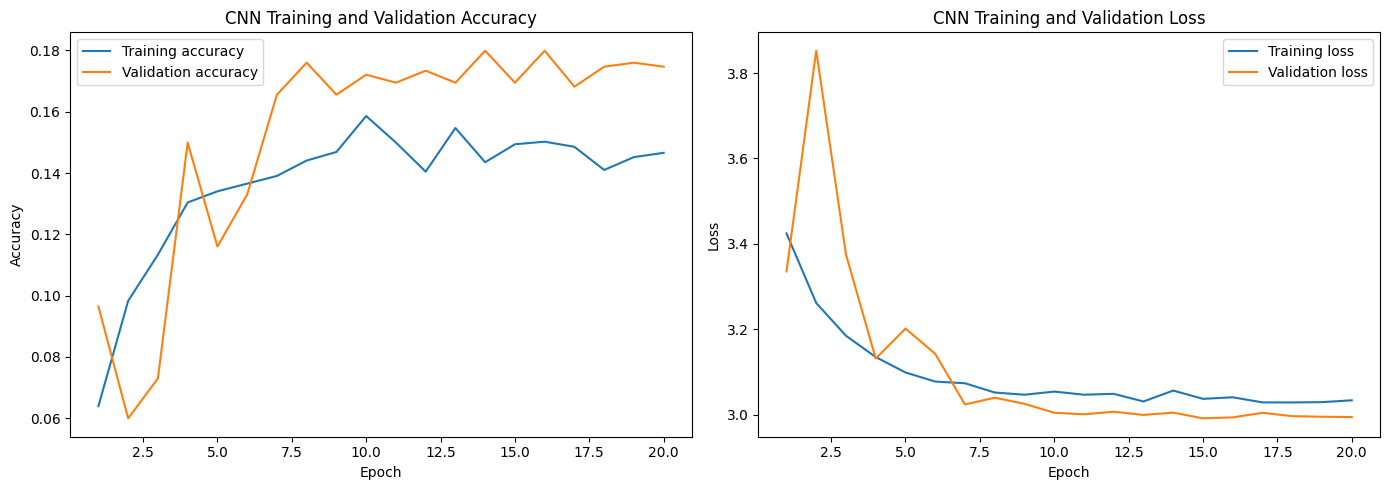

In [17]:
#final training curve 
train_acc = final_history.history["accuracy"]
val_acc   = final_history.history["val_accuracy"]
train_loss = final_history.history["loss"]
val_loss   = final_history.history["val_loss"]

epochs = range(1, len(train_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_acc, label="Training accuracy")
ax1.plot(epochs, val_acc, label="Validation accuracy")
ax1.set_title("CNN Training and Validation Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(epochs, train_loss, label="Training loss")
ax2.plot(epochs, val_loss, label="Validation loss")
ax2.set_title("CNN Training and Validation Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

In [19]:
# After all your training cells have run, check this:
print("Architecture results:")
for r in architecture_results:
    print(f"  {r['name']}: val_acc={r['best_val_acc']:.4f}, val_loss={r['best_val_loss']:.4f}")

print("\nLearning rate results:")
for r in lr_results:
    print(f"  lr={r['lr']}: val_acc={r['best_val_acc']:.4f}, val_loss={r['best_val_loss']:.4f}")

print("\nFinal test accuracy:")
test_loss, test_acc, test_top3 = final_model.evaluate(test_ds, verbose=0)
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Test Loss:     {test_loss:.4f}")

Architecture results:
  A1_small: val_acc=0.1747, val_loss=2.9432
  A2_medium: val_acc=0.1695, val_loss=2.9762
  A3_strong_reg: val_acc=0.1512, val_loss=3.1462

Learning rate results:
  lr=0.001: val_acc=0.1969, val_loss=2.9497
  lr=0.0003: val_acc=0.1591, val_loss=3.0320
  lr=0.0001: val_acc=0.1486, val_loss=3.1399

Final test accuracy:
  Test Accuracy: 0.1641
  Test Loss:     2.9872
